# SCENIC Analysis Workflow Template

This notebook provides a template workflow for performing SCENIC (Single-Cell Regulatory Network Inference and Clustering) analysis on single-cell RNA-seq data.

## Important Notes

- **This is a workflow template**, not a complete protocol. For detailed methodology and best practices, please refer to the official [SCENIC protocol](https://github.com/aertslab/SCENICprotocol).
- This template is configured for **mouse data (mm10)**. Adjust database paths and parameters for other species.
- Ensure you have completed the preprocessing steps for your own dataset before performing the SCENIC analysis.
- Ensure you have downloaded the required SCENIC databases from [https://resources.aertslab.org/cistarget/](https://resources.aertslab.org/cistarget/) before running the analysis.

## Workflow Overview

1. SCENIC analysis (GRNBoost2, cisTarget, AUCell)
2. Integration and visualization
3. Calculation of RSS (Regulon Specifity Score)

**Reference**: Aibar, S. et al. (2017). SCENIC: single-cell regulatory network inference and clustering. *Nature Methods*, 14(11), 1083-1086.


## Step 1: SCENIC Analysis

Please run `pySCENIC-preprocessing.ipynb` first to prepare your data. That notebook:
- Imports and merges sample data
- Performs quality control and filtering
- Normalizes and preprocesses the expression data
- Performs dimensionality reduction (PCA, UMAP)
- Clusters cells and identifies marker genes
- Checks for batch effects
- Saves processed data to `pre_processing_results/processed_adata.h5ad` and `pre_processing_results/merged_cleaned.loom`

**Note**: The preprocessing notebook must be completed before running SCENIC analysis.

---

SCENIC analysis consists of three main steps that should be run from the command line. The analysis can be computationally intensive, so ensure adequate resources are available.

### Step 1.1: GRNBoost2 (Gene Regulatory Network Inference)

Infer gene regulatory networks using GRNBoost2. This identifies potential transcription factor targets.

```bash
# Run from terminal or use ! prefix in Jupyter
pyscenic grn \
    <input_loom_file> \
    <transcription_factor_list> \
    -o adj.tsv \
    --num_workers 10
```

**Example with template variables:**
```bash
pyscenic grn merged_cleaned.loom resources/allTFs_mm.txt -o adjacencies.tsv --num_workers 10
```

### Step 1.2: cisTarget (Regulon Prediction)

Identify regulons (transcription factors and their target genes) using cisTarget databases.

**Example with template variables:**
```bash
pyscenic ctx adj.tsv {f_db_mm10_10kb} {f_db_mm10_500bp} \
    --annotations_fname {motifs_list} \
    --expression_mtx_fname {input_loom_file} \
    --output regulons.csv \
    --num_workers 10
```

### Step 1.3: AUCell (Regulon Activity Scoring)

Calculate regulon activity scores for each cell using AUCell.

**Example with template variables:**
```bash
pyscenic aucell {input_loom_file} regulons.csv \
    --output pyscenic_output.loom \
    --num_workers 10
```

**Important**: 
- Adjust `--num_workers` based on available computational resources
- Ensure all database files are downloaded and paths are correct

## Step 2: Integrate SCENIC Results with Pre-processed Data

After completing SCENIC analysis, this step integrates the regulon activity scores with your pre-processed data for RSS score calculation.

**What this step does:**
1. Loads the saved pre-processed AnnData object (from `processed_adata.h5ad`)
2. Loads pySCENIC output (from `pyscenic_output.loom`) containing AUC matrix
3. Matches cells between the two datasets
4. Adds AUC matrix to AnnData object
5. Saves integrated AnnData ready for RSS score calculation (`processed_adata_with_scenic.h5ad`)

**For RSS score calculation, you need:**
- AUC matrix (regulon activity scores) - added to `adata.obsm['X_regulonsAUC']`
- Cluster annotations - available in `adata.obs['leiden']`
- Regulon names - available in `adata.uns['regulons']`


In [1]:
# Import libraries
import os
import numpy as np
import pandas as pd
import scanpy as sc
import loompy as lp
import matplotlib.pyplot as plt
import seaborn as sns
from pyscenic.rss import regulon_specificity_scores
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import rgb2hex


### 2.1 Load the saved processed AnnData object (contains clustering, UMAP, metadata) and pySCENIC output

In [2]:
# Get current working directory path as base for all file operations
wdir = os.getcwd()

# Create results directory
results_dir = os.path.join(wdir, "results")
os.makedirs(results_dir, exist_ok=True)

preprocessing_dir = os.path.join(wdir, "pre_processing_results")

# Define paths for input files
f_pyscenic_output = os.path.join(results_dir, "cistarget_results", "pyscenic_output.loom")  # Path to pySCENIC AUCell output (loom format with regulon activity scores)
f_processed_adata = os.path.join(preprocessing_dir, "processed_adata.h5ad")  # Path to preprocessed single-cell data (h5ad format with clustering/UMAP) generated in preprocessing step
print("Integrating SCENIC Results with Pre-processed Data")

# Load the saved processed AnnData object (contains clustering, UMAP, metadata)
adata = sc.read_h5ad(f_processed_adata)  # Read h5ad file into AnnData object - contains expression matrix, cell metadata, embeddings
print(f"Loaded AnnData: {adata.shape} (cells x genes)")

# Load pySCENIC output
lf = lp.connect(f_pyscenic_output, mode='r', validate=False) 
print(f"   Loom file shape: {lf.shape}")
print(f"   Column attributes: {list(lf.ca.keys())}")

Integrating SCENIC Results with Pre-processed Data
Loaded AnnData: (9347, 2144) (cells x genes)
   Loom file shape: (17068, 9347)
   Column attributes: ['CellID', 'RegulonsAUC', 'mouse', 'nGene', 'nUMI', 'sample']


### 2.2 Extract regulon activity (AUC) matrix, regulon names and thresholds

In [3]:
auc_mtx = pd.DataFrame(
    lf.ca.RegulonsAUC,  # lf.ca = column attributes. RegulonsAUC contains AUC scores for each regulon per cell
    index=lf.ca.CellID  # Use cell IDs as row index for later matching
)
print(f"Extracted AUC matrix: {auc_mtx.shape} (cells x regulons)")

# Extract regulon names from loom file row attributes
if 'Regulons' in lf.ra.keys():  # lf.ra = row attributes (gene/regulon-level data)
    regulons = lf.ra.Regulons  # Get regulon names stored as row attribute
else:
    regulons = auc_mtx.columns.tolist()  # Fallback: use column names from AUC matrix if Regulons attribute doesn't exist
print(f"Number of regulons: {len(regulons)}")

# Extract thresholds if available (useful for downstream analysis)
# Thresholds indicate the AUC cutoff for considering a regulon as "active" in a cell
rt = {}
if 'RegulonsAUC_thresholds' in lf.ca.keys():  # Check if thresholds were computed during AUCell step
    thresholds = lf.ca.RegulonsAUC_thresholds  # Extract threshold values from loom file
    if isinstance(thresholds, np.ndarray):  # Verify thresholds are in numpy array format
        if thresholds.dtype.names:  # Check if structured array with named fields
            for name in thresholds.dtype.names:  # Iterate through each regulon name in structured array
                rt[name] = float(thresholds[name][0]) if len(thresholds[name]) > 0 else 0.0  # Extract threshold value, default to 0.0 if empty
        else:  # Handle simple array without named fields
            for i, reg_name in enumerate(regulons[:len(thresholds)]):  # Iterate through regulons matching threshold array length
                rt[reg_name] = float(thresholds[i])  # Map each threshold to its corresponding regulon name
    print(f"Extracted {len(rt)} regulon thresholds")

Extracted AUC matrix: (9347, 342) (cells x regulons)
Number of regulons: 17068


### 2.3 Match cells between SCENIC output and AnnData object

In [4]:
# Get cell IDs from both data sources
scenic_cellids = pd.Series(lf.ca.CellID)  # Extract cell IDs from loom file as pandas Series
anndata_cellids = pd.Series(adata.obs.index)  # Extract cell IDs from AnnData object (stored as index of obs DataFrame)

# Match cells between SCENIC output and AnnData by exact cell ID match
common_cells = scenic_cellids[scenic_cellids.isin(anndata_cellids)]  # Filter SCENIC cell IDs that exist in AnnData
print(f"Found {len(common_cells)} common cells")

# Subset AUC matrix to matched cells
auc_mtx_matched = auc_mtx.loc[common_cells]  # Keep only cells present in both datasets

# Subset AnnData to common cells (preserve all metadata, clustering, embeddings)
adata_matched = adata[common_cells].copy()  # Create copy of AnnData with only matched cells


Found 9347 common cells


### 2.4 Add AUC scores to AnnData

In [5]:
# Store AUC matrix in obsm
adata_matched.obsm['X_regulonsAUC'] = auc_mtx_matched.values  # Store as numpy array; obsm stores matrices with shape (n_cells, n_features)

# Store regulon names and thresholds in uns (for metadata that doesn't fit structured slots)
adata_matched.uns['regulons'] = auc_mtx_matched.columns.tolist()  # List of regulon names for reference
adata_matched.uns['regulon_thresholds'] = rt  # Dictionary of activity thresholds per regulon

# Add as individual columns for easier plotting and analysis
regulon_obs = pd.DataFrame(
    {f'regulon_{reg_name}': auc_mtx_matched[reg_name].values  # Create column for each regulon with 'regulon_' prefix
     for reg_name in auc_mtx_matched.columns}, 
    index=adata_matched.obs.index  # Match index to AnnData cell IDs for proper alignment
)
adata_matched.obs = pd.concat([adata_matched.obs, regulon_obs], axis=1)  # Concatenate horizontally (axis=1) to add new columns to existing obs DataFrame

print(f"Matched {len(common_cells)} cells")
print(f"Added AUC scores to AnnData")

Matched 9347 cells
Added AUC scores to AnnData


### 2.5 Save integrated AnnData object to further include RSS scores

In [6]:
# Define output path for integrated AnnData file
f_integrated_adata = os.path.join(preprocessing_dir, "processed_data_with_scenic.h5ad")  # Construct full path for saving integrated data
adata_matched.write(f_integrated_adata)  # Write AnnData object to h5ad file

# Update adata to use matched version for downstream analysis
adata = adata_matched.copy()  # Create copy to avoid reference issues

# Close loom file connection to release file handle and free memory
lf.close()

## Step 3: Calculate RSS (Regulon Specificity Scores)

Calculate RSS scores to identify which regulons are specific to each cluster.

**RSS scores** measure how specific each regulon is to each cluster/cell type.
Higher RSS = regulon is more specific to that cluster.

After cell type annotation, you can map cell type names to clusters to get RSS by cell type.


In [7]:
# Extract regulon AUC matrix from AnnData object (stored in obsm during integration step)
auc_matrix = adata.obsm['X_regulonsAUC']  # Get the AUC matrix (cells x regulons)
if hasattr(auc_matrix, 'toarray'):  # Check if matrix is sparse (scipy sparse matrix has toarray method)
    auc_matrix = auc_matrix.toarray()  # Convert sparse matrix to dense numpy array for compatibility with RSS function

# Convert to DataFrame for RSS calculation - RSS function requires pandas DataFrame input
regulon_names = adata.uns['regulons']  # Retrieve regulon names stored during integration
auc_df = pd.DataFrame(auc_matrix,
                      index=adata.obs_names,
                      columns=regulon_names)

# Get cluster labels for each cell from Leiden clustering results
cluster_labels = adata.obs['leiden'].astype(str)  # Convert to string type for consistent grouping (RSS function expects strings)

print(f"\nAUC matrix shape: {auc_df.shape} (cells x regulons)")
print(f"Number of regulons: {len(regulon_names)}")
print(f"Number of clusters: {cluster_labels.nunique()}")
print(f"\nCluster distribution:")
print(cluster_labels.value_counts().sort_index())

# Calculate RSS scores using pySCENIC function
rss_scores = regulon_specificity_scores(auc_df, cluster_labels)  # Returns DataFrame with clusters as rows, regulons as columns

# Transpose to have regulons as rows and clusters as columns (more intuitive for visualization)
rss_scores = rss_scores.T  # Now rows = regulons, columns = clusters

print(f"\n✓ RSS scores calculated: {rss_scores.shape} (regulons x clusters)")
print(f"  Rows = regulons, Columns = clusters")
print(f"\nRSS scores preview (first 5 regulons, all clusters):")
print(rss_scores.head())



AUC matrix shape: (9347, 342) (cells x regulons)
Number of regulons: 342
Number of clusters: 16

Cluster distribution:
0     2629
1     1315
10     234
11     100
12      74
13      73
14      60
15      29
2     1206
3      891
4      751
5      529
6      413
7      400
8      363
9      280
Name: leiden, dtype: int64

✓ RSS scores calculated: (342, 16) (regulons x clusters)
  Rows = regulons, Columns = clusters

RSS scores preview (first 5 regulons, all clusters):
                  8         2         4        12         1         0  \
Ar(+)      0.183263  0.375527  0.312085  0.173570  0.196427  0.232465   
Arid3a(+)  0.204777  0.229926  0.211641  0.196978  0.312262  0.374386   
Arid5b(+)  0.170922  0.353443  0.264834  0.173787  0.240222  0.412081   
Arnt(+)    0.214204  0.292912  0.263849  0.185065  0.259329  0.362810   
Atf2(+)    0.196231  0.246897  0.226952  0.193007  0.332109  0.449800   

                  9         6         7         3        10         5  \
Ar(+)      0.24

### Visualize RSS scores

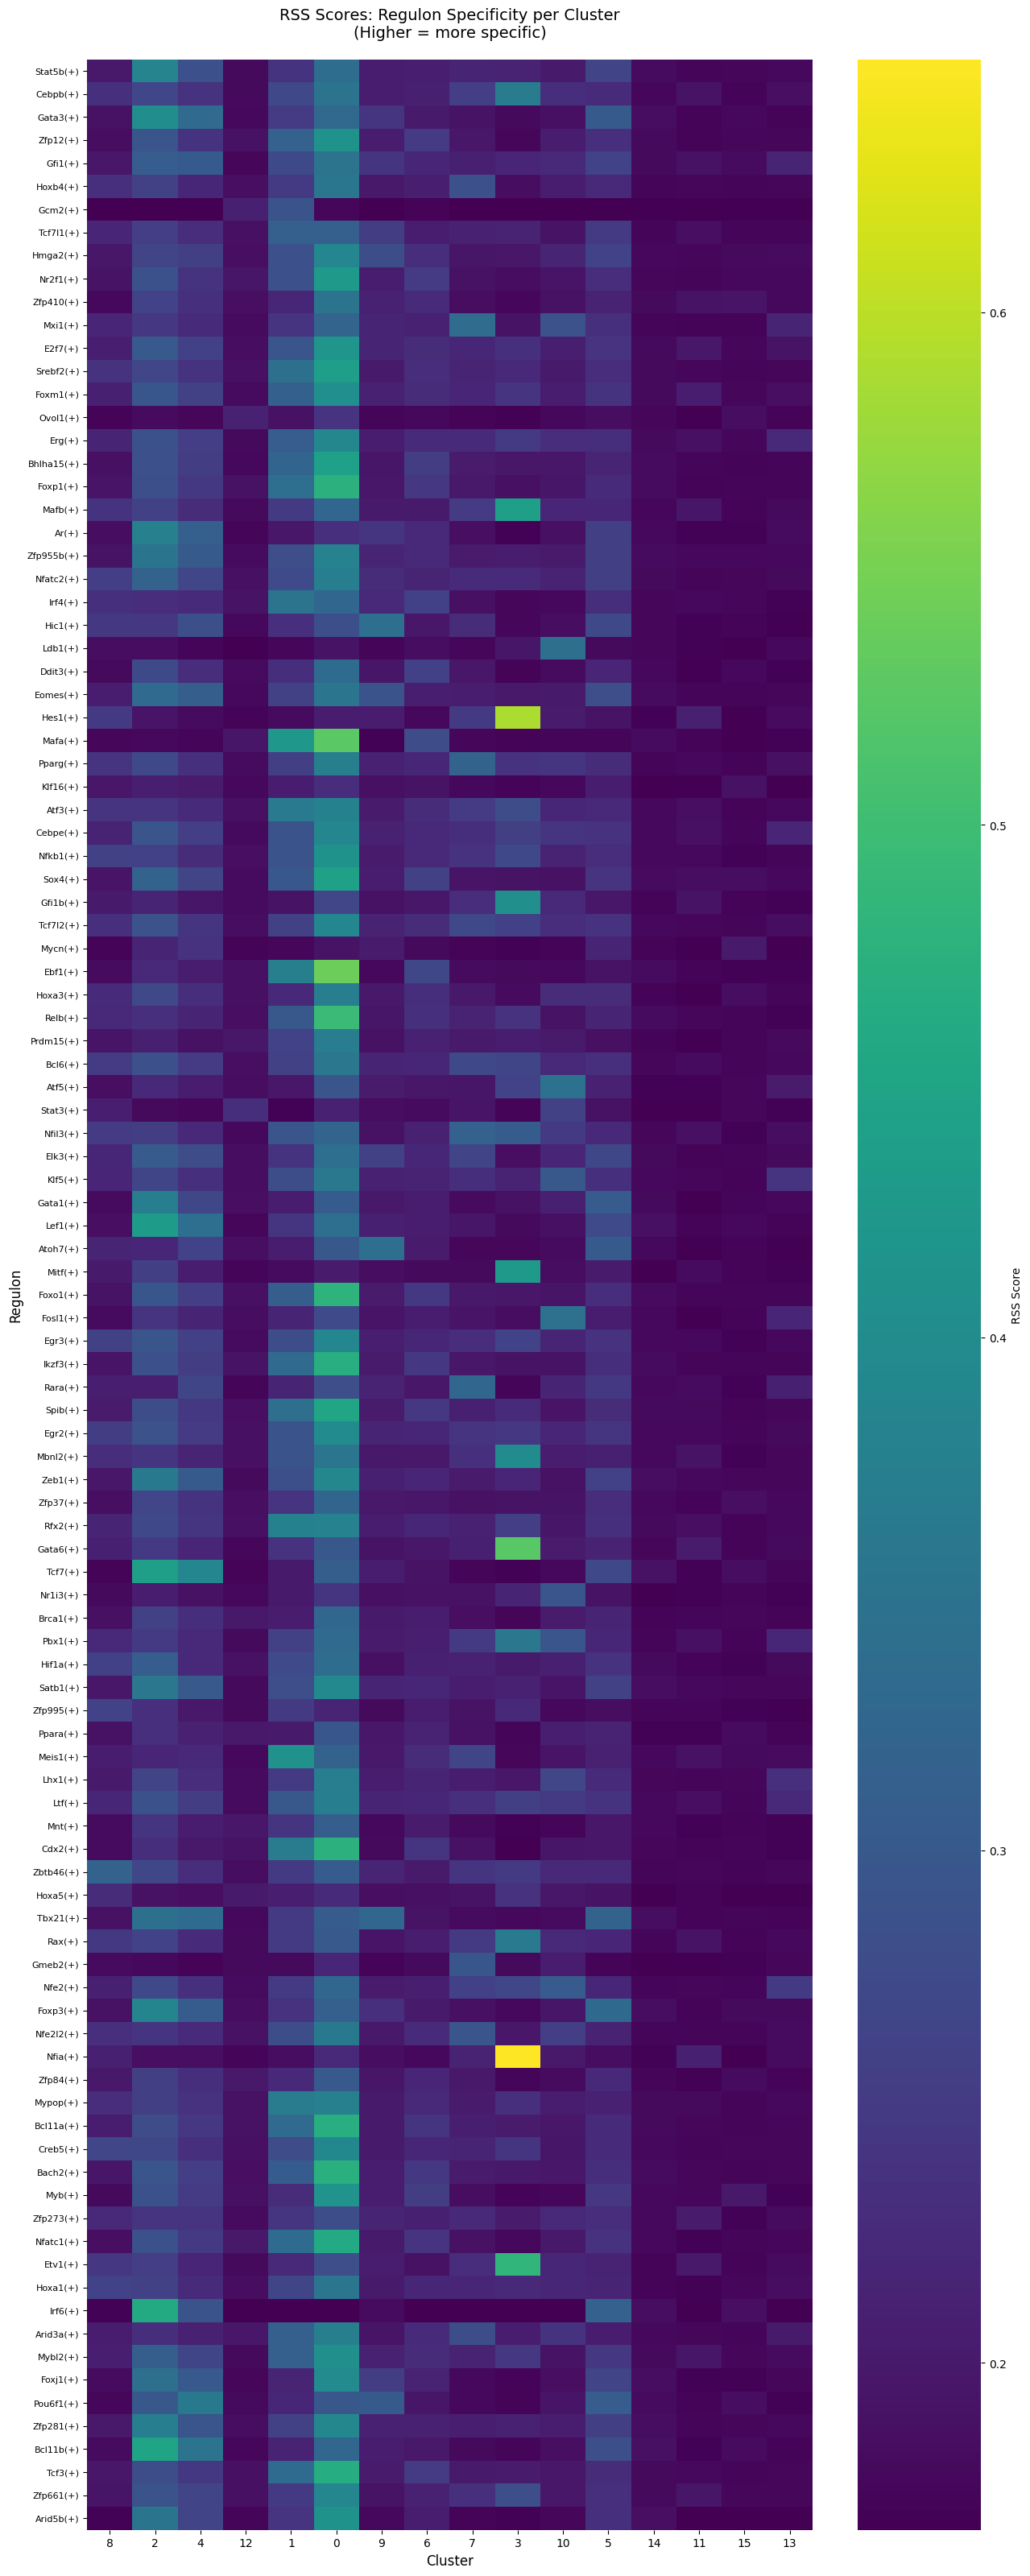

In [8]:
# For General RSS Score Heatmap: Select top regulons per cluster for visualization (top 10 per cluster)
top_regulons_per_cluster = {}  # Dictionary to store top 10 regulons for each cluster
for cluster in rss_scores.columns:  # Iterate through each cluster
    top_regulons_per_cluster[cluster] = rss_scores[cluster].nlargest(10).index.tolist() 

# Get unique top regulons
top_regulons = list(set([reg for regs in top_regulons_per_cluster.values() for reg in regs])) 
rss_subset = rss_scores.loc[top_regulons]  # Subset RSS DataFrame to only include top regulons

# Create general heatmap figure
fig, ax = plt.subplots(figsize=(max(10, len(rss_subset.columns) * 0.8),
                                 max(12, len(rss_subset) * 0.3))) 
sns.heatmap(rss_subset, annot=False, fmt='.2f', cmap='viridis',
            cbar_kws={'label': 'RSS Score'}, ax=ax)
ax.set_title('RSS Scores: Regulon Specificity per Cluster\n(Higher = more specific)',
             fontsize=14, pad=20)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Regulon', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

# Save heatmap to file
rss_heatmap_file = os.path.join(results_dir, 'rss_scores_heatmap_top_regulons.png')
plt.savefig(rss_heatmap_file, dpi=300, bbox_inches='tight')
plt.show()


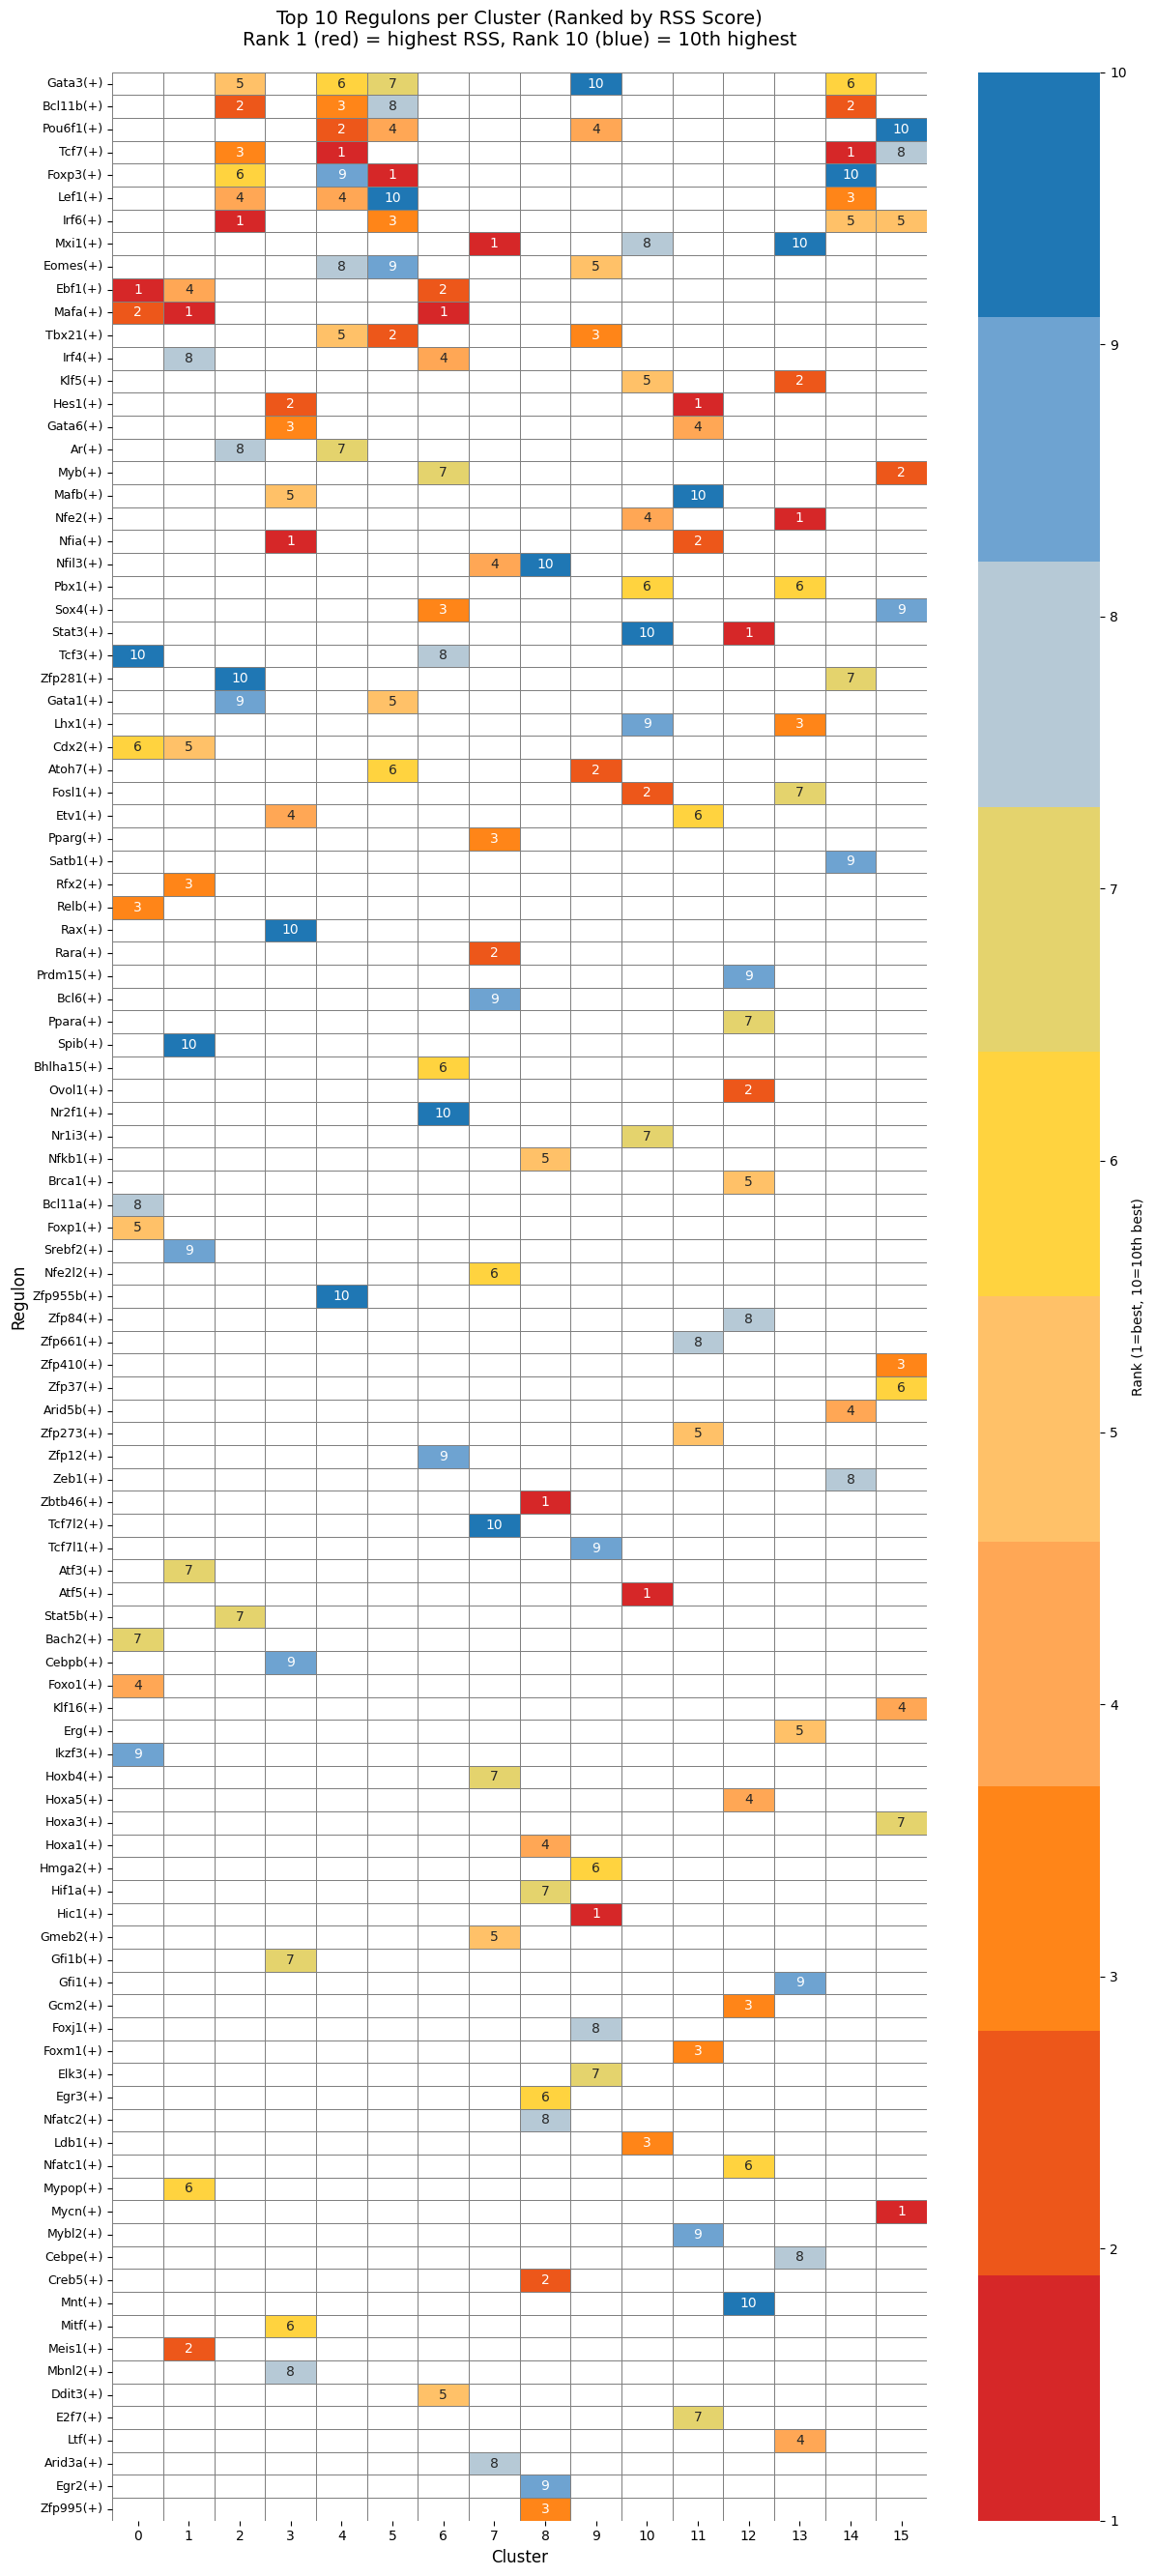

In [9]:
# For Rank-based Heatmap (Top N regulons per cluster)
# This visualization shows which regulons rank highest for each cluster, making cross-cluster comparisons easier

# Configuration: Number of top regulons to show per cluster
TOP_N_REGULONS = 10  # Change this to show more (e.g., 40 for top 40)

# Get top N regulons for each cluster and create rank matrix
# Rank 1 (highest RSS) = red, Rank N = blue
rank_matrix = pd.DataFrame(index=rss_scores.index, columns=rss_scores.columns, dtype=float)
rank_matrix[:] = np.nan  # Initialize all values with NaN (cells not in top N will remain NaN and appear blank)

# For each cluster, assign ranks (1 to TOP_N_REGULONS) to top N regulons
for cluster in rss_scores.columns:  # Iterate through each cluster
    top_n = rss_scores[cluster].nlargest(TOP_N_REGULONS)  # Get top N regulons by RSS score for this cluster
    for rank, regulon in enumerate(top_n.index, 1):  # enumerate with start=1 gives ranks 1, 2, 3, ...
        rank_matrix.loc[regulon, cluster] = rank  # Assign rank to corresponding regulon-cluster cell

# Get all regulons that are in top N for at least one cluster
top_regulons_all = rank_matrix.dropna(how='all').index.tolist()  # dropna(how='all') removes rows where ALL values are NaN
rank_subset = rank_matrix.loc[top_regulons_all]  # Subset to only regulons that appear in at least one cluster's top N

# This puts "global" regulators (specific to many clusters) at the top
regulon_counts = rank_subset.notna().sum(axis=1).sort_values(ascending=False) 
rank_subset = rank_subset.loc[regulon_counts.index]  # Reorder rows by frequency

# Sort clusters numerically for consistent ordering
cluster_order = sorted(rank_subset.columns, key=lambda x: int(x) if x.isdigit() else float('inf'))
rank_subset = rank_subset[cluster_order]

# Define color scheme based on number of ranks to display
if TOP_N_REGULONS <= 5:
    colors = ['#d62728', '#ff7f0e', '#ffbb78', '#aec7e8', '#1f77b4']
    n_bins = TOP_N_REGULONS
else:
    n_bins = TOP_N_REGULONS
    # Create gradient: red -> orange -> yellow -> light blue -> blue
    base_colors = ['#d62728', '#ff7f0e', '#ffbb78', '#ffd92f', '#aec7e8', '#1f77b4']
    # Interpolate for more colors if needed
    if TOP_N_REGULONS > 6:
        cmap_temp = LinearSegmentedColormap.from_list('temp', base_colors, N=256)
        colors = [rgb2hex(cmap_temp(i)) for i in np.linspace(0, 1, TOP_N_REGULONS)]
    else:
        colors = base_colors[:TOP_N_REGULONS]

cmap_custom = LinearSegmentedColormap.from_list('rank_cmap', colors, N=n_bins)

# Determine if we should annotate cells with rank numbers (only for smaller matrices)
annotate_ranks = TOP_N_REGULONS <= 20

# Create figure with dynamic sizing based on data dimensions
fig, ax = plt.subplots(figsize=(max(12, len(rank_subset.columns) * 0.6),
                                 max(14, len(rank_subset) * 0.25)))
sns.heatmap(rank_subset, annot=annotate_ranks, fmt='.0f', cmap=cmap_custom,
            vmin=1, vmax=TOP_N_REGULONS,
            cbar_kws={'label': f'Rank (1=best, {TOP_N_REGULONS}={TOP_N_REGULONS}th best)',
                     'ticks': list(range(1, min(TOP_N_REGULONS+1, 11))) if TOP_N_REGULONS <= 10 else [1, TOP_N_REGULONS//2, TOP_N_REGULONS]},
            ax=ax, linewidths=0.5, linecolor='gray')
ax.set_title(f'Top {TOP_N_REGULONS} Regulons per Cluster (Ranked by RSS Score)\nRank 1 (red) = highest RSS, Rank {TOP_N_REGULONS} (blue) = {TOP_N_REGULONS}th highest', 
             fontsize=14, pad=20)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Regulon', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# Save ranked heatmap to file
rss_ranked_heatmap_file = os.path.join(results_dir, f'rss_scores_heatmap_top{TOP_N_REGULONS}_ranked.png')
plt.savefig(rss_ranked_heatmap_file, dpi=300, bbox_inches='tight')
plt.show()

### Print top regulons for each cluster with ranks

In [10]:
# Show top regulons for each cluster with ranks as text output
print(f"\n=== Top {TOP_N_REGULONS} Regulons per Cluster (by RSS score) ===")
print("(These are the most specific regulons for each cluster)\n")

# Iterate through clusters in numerical order for organized output
for cluster in sorted(rss_scores.columns, key=lambda x: int(x) if x.isdigit() else float('inf')):  # Sort clusters numerically
    top_regulons = rss_scores[cluster].nlargest(TOP_N_REGULONS)  # Get top N regulons for this cluster, sorted by RSS score descending
    print(f"Cluster {cluster}:")
    for i, (regulon, score) in enumerate(top_regulons.items(), 1):
        print(f"  Rank {i}. {regulon}: RSS={score:.4f}")
    print()


=== Top 10 Regulons per Cluster (by RSS score) ===
(These are the most specific regulons for each cluster)

Cluster 0:
  Rank 1. Ebf1(+): RSS=0.5418
  Rank 2. Mafa(+): RSS=0.5256
  Rank 3. Relb(+): RSS=0.4943
  Rank 4. Foxo1(+): RSS=0.4785
  Rank 5. Foxp1(+): RSS=0.4760
  Rank 6. Cdx2(+): RSS=0.4749
  Rank 7. Bach2(+): RSS=0.4742
  Rank 8. Bcl11a(+): RSS=0.4704
  Rank 9. Ikzf3(+): RSS=0.4704
  Rank 10. Tcf3(+): RSS=0.4658

Cluster 1:
  Rank 1. Mafa(+): RSS=0.4237
  Rank 2. Meis1(+): RSS=0.4086
  Rank 3. Rfx2(+): RSS=0.3767
  Rank 4. Ebf1(+): RSS=0.3732
  Rank 5. Cdx2(+): RSS=0.3682
  Rank 6. Mypop(+): RSS=0.3666
  Rank 7. Atf3(+): RSS=0.3635
  Rank 8. Irf4(+): RSS=0.3516
  Rank 9. Srebf2(+): RSS=0.3436
  Rank 10. Spib(+): RSS=0.3414

Cluster 2:
  Rank 1. Irf6(+): RSS=0.4597
  Rank 2. Bcl11b(+): RSS=0.4492
  Rank 3. Tcf7(+): RSS=0.4377
  Rank 4. Lef1(+): RSS=0.4322
  Rank 5. Gata3(+): RSS=0.4016
  Rank 6. Foxp3(+): RSS=0.3870
  Rank 7. Stat5b(+): RSS=0.3841
  Rank 8. Ar(+): RSS=0.3755


### Save RSS scores to object

In [11]:
# Save RSS scores to CSV files for external analysis and archiving
rss_output_dir = os.path.join(results_dir, 'rss_scores')
os.makedirs(rss_output_dir, exist_ok=True)

# Save full RSS scores matrix (regulons x clusters) as CSV
rss_file = os.path.join(rss_output_dir, 'rss_scores_per_cluster.csv')
rss_scores.to_csv(rss_file)

# Save top regulons per cluster in a summarized format for quick reference
top_regulons_dict = {} 
for cluster in rss_scores.columns: 
    top_10 = rss_scores[cluster].nlargest(10) 
    top_regulons_dict[cluster] = {
        'regulons': top_10.index.tolist(),
        'rss_scores': top_10.values.tolist()
    }

# Create summary DataFrame with one row per cluster showing top 10 regulons
top_regulons_df = pd.DataFrame({
    'cluster': list(top_regulons_dict.keys()),
    'top_10_regulons': [', '.join(d['regulons']) for d in top_regulons_dict.values()],
    'top_10_rss_scores': [', '.join([f'{s:.4f}' for s in d['rss_scores']]) for d in top_regulons_dict.values()]
})
top_regulons_file = os.path.join(rss_output_dir, 'top_regulons_per_cluster.csv')
top_regulons_df.to_csv(top_regulons_file, index=False)

# Also add RSS scores to AnnData object for easy access in downstream analysis
adata.uns['rss_scores'] = rss_scores

# Re-save the AnnData object with RSS scores included for complete data package
f_integrated_adata = os.path.join(results_dir, "processed_data_with_scenic.h5ad")
adata.write(f_integrated_adata)


## Step 14: Cell Type Annotation

**Cell type annotation has been moved to a separate notebook.**

Please run `manual_annotation_sctypedb.ipynb` to annotate your cells. That notebook:
- Loads the processed data from this notebook (`processed_data_with_scenic.h5ad`)
- Implements multiple annotation methods (marker-based, reference-based, GSEA)
- Saves annotated data to `results/annotated_adata_with_scenic.h5ad`

**Note**: The annotation notebook requires additional packages (celltypist, scvi-tools, gseapy) which may need a separate container.


# Info session

In [12]:
sc.logging.print_versions()

-----
anndata     0.8.0
scanpy      1.9.1
-----
PIL                         9.3.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        25.3.0
attrs                       25.3.0
babel                       2.17.0
backcall                    0.2.0
certifi                     2022.09.24
cffi                        1.15.1
charset_normalizer          2.1.1
cloudpickle                 2.2.0
cycler                      0.10.0
cython_runtime              NA
cytoolz                     0.12.0
dask                        2022.11.1
dateutil                    2.8.2
debugpy                     1.6.3
decorator                   5.1.1
defusedxml                  0.7.1
entrypoints                 0.4
exceptiongroup              1.2.2
executing                   1.2.0
fastjsonschema              NA
fqdn                        NA
fsspec                      2022.11.0
h5py                        3.7.0
idna                        3.4
